In [23]:
# Imports & configuration.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from joblib import dump
from xgboost import XGBClassifier

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Dataset obtained from `https://www.unb.ca/cic/datasets/ids-2017.html`
DATASET_PREFIX = 'ids_2017/TrafficLabelling/'
DATASET_SOURCES = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
]

In [2]:
# Dataset.

# The original PCAP files were downloaded. These `.pcap` files are actual `.pcapng` files,
# so they were converted using to `.pcap` using the following command:
#
# `tshark -r <file>.pcapng -w <file>.pcap -F pcap`
#
# They were then processed using `ntlflowlyzer` in order to convert them into `.csv` files.

# Compute the paths at which the dataset is located.
dataset_paths = (Path(DATASET_PREFIX) / source for source in DATASET_SOURCES)

# Load dataset from files.
core_dataset = pd.concat(
    (
        pd.read_csv(
            path,
            index_col=None,
            header=0,
            encoding="cp1252",
            low_memory=False
        )
        for path in dataset_paths
    ),
    axis=0,
    ignore_index=True
)

core_dataset.head(5)

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,4.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4.0,4.0,4.0,4.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,5.000000e+05,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,329.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,2.000000e+06,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,329.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,2.000000e+06,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,329.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0,192.168.10.5,49188.0,6.0,03/07/2017 08:55:58,1.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,2.000000e+06,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,329.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80.0,192.168.10.14,49486.0,6.0,03/07/2017 08:56:22,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,6.666667e+05,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,245.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


<class 'pandas.DataFrame'>
RangeIndex: 3119345 entries, 0 to 3119344
Data columns (total 85 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Flow ID                       str    
 1    Source IP                    str    
 2    Source Port                  float64
 3    Destination IP               str    
 4    Destination Port             float64
 5    Protocol                     float64
 6    Timestamp                    str    
 7    Flow Duration                float64
 8    Total Fwd Packets            float64
 9    Total Backward Packets       float64
 10  Total Length of Fwd Packets   float64
 11   Total Length of Bwd Packets  float64
 12   Fwd Packet Length Max        float64
 13   Fwd Packet Length Min        float64
 14   Fwd Packet Length Mean       float64
 15   Fwd Packet Length Std        float64
 16  Bwd Packet Length Max         float64
 17   Bwd Packet Length Min        float64
 18   Bwd Packet Length Mean       flo

/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.829385e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0,2.830743e+06,2830743.0,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,4.112886e+04,8.071483e+03,9.880341e+00,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,8.708495e+02,4.104958e+01,3.059493e+02,3.353257e+02,inf,inf,1.298449e+06,2.919271e+06,9.182475e+06,1.623796e+05,1.448296e+07,2.610193e+06,3.266957e+06,9.042939e+06,1.021893e+06,9.893830e+06,1.805784e+06,1.485973e+06,4.684692e+06,9.672614e+05,4.644646e-02,0.0,1.112782e-04,0.0,-2.599739e+04,-2.273275e+03,6.386535e+04,6.995192e+03,1.643450e+01,9.504024e+02,1.719444e+02,2.949756e+02,4.861548e+05,3.537976e-02,4.644646e-02,2.423392e-04,2.980705e-01,3.158443e-01,9.482316e-02,1.112782e-04,2.433990e-04,6.835004e-01,1.919837e+02,5.820194e+01,3.059493e+02,-2.599739e+04,0.0,0.0,0.0,0.0,0.0,0.0,9.361160e+00,5.492919e+02,1.039377e+01,1.616230e+04,6.989837e+03,1.989433e+03,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,2.229494e+04,1.828363e+04,5.261922e+00,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,1.946367e+03,6.886260e+01,6.052568e+02,8.396932e+02,NaN,NaN,4.507944e+06,8.045870e+06,2.445954e+07,2.950282e+06,3.357581e+07,9.525722e+06,9.639055e+06,2.452916e+07,8.591436e+06,2.873661e+07,8.887197e+06,6.278469e+06,1.716095e+07,8.308983e+06,2.104500e-01,0.0,1.054826e-02,0.0,2.105286e+07,1.452209e+06,2.475371e+05,3.815170e+04,2.523772e+01,2.028229e+03,3.054915e+02,6.318001e+02,1.647490e+06,1.847378e-01,2.104500e-01,1.556536e-02,4.574107e-01,4.648513e-01,2.929706e-01,1.054826e-02,1.559935e-02,6.804920e-01,3.318603e+02,1.860912e+

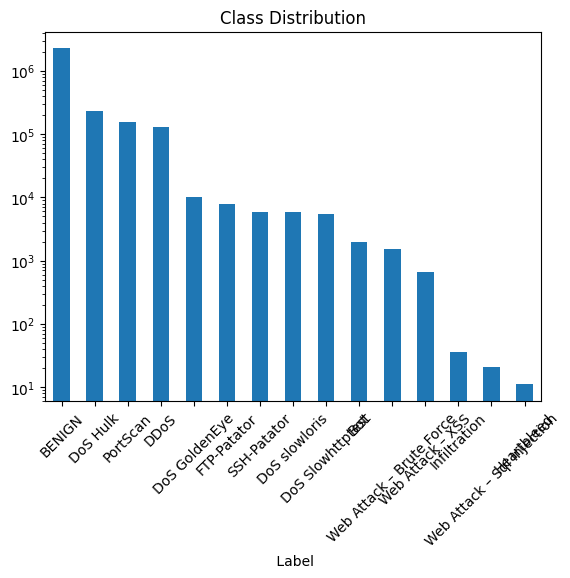

NaNs:


0     2829385
85     288602
1        1358
Name: count, dtype: int64

Infinities:


0    3116478
2       1509
1       1358
Name: count, dtype: int64

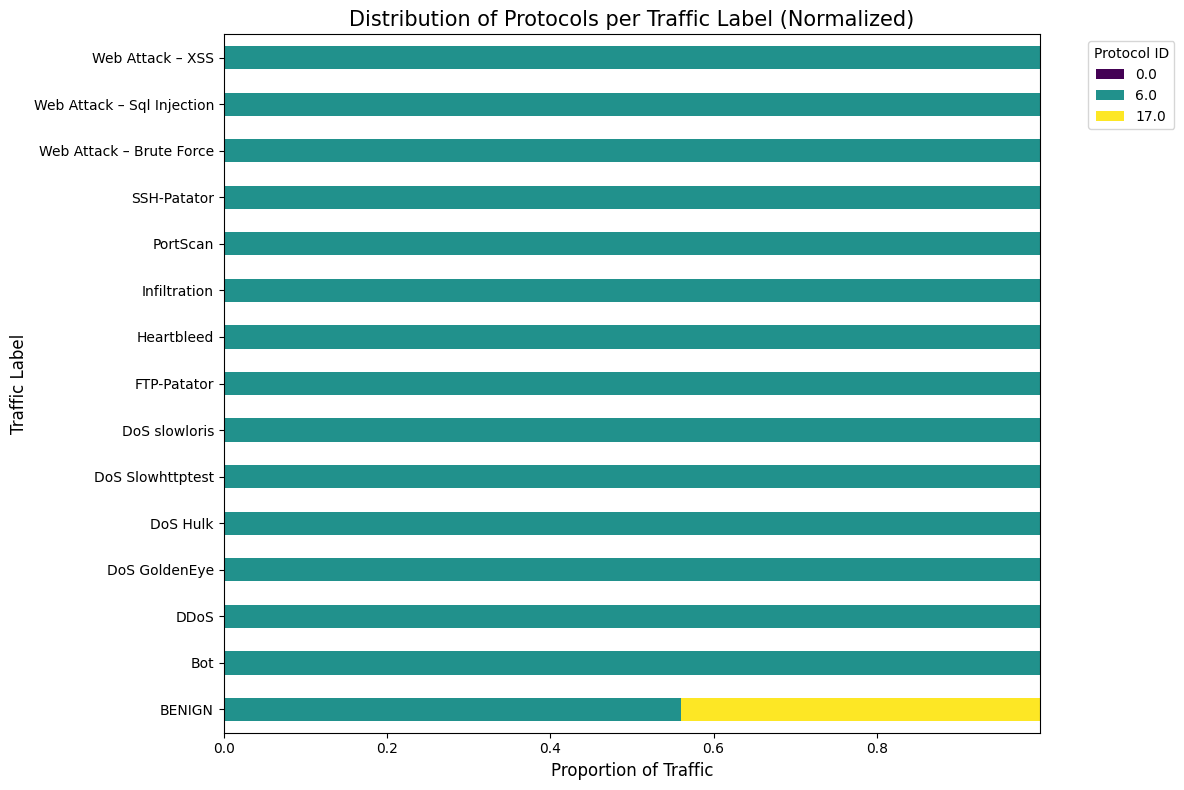

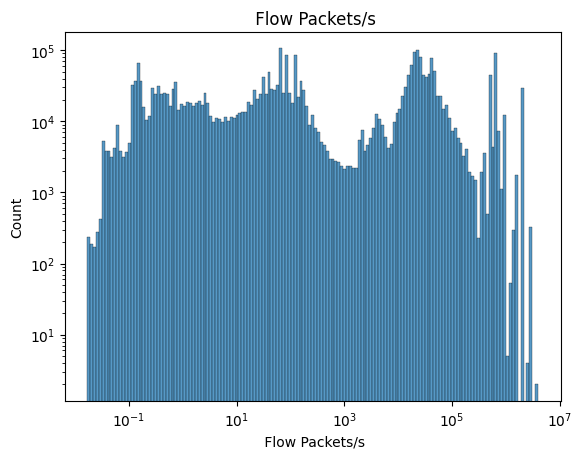

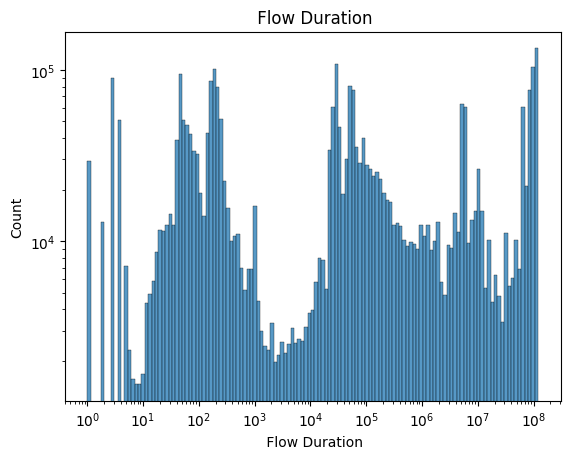

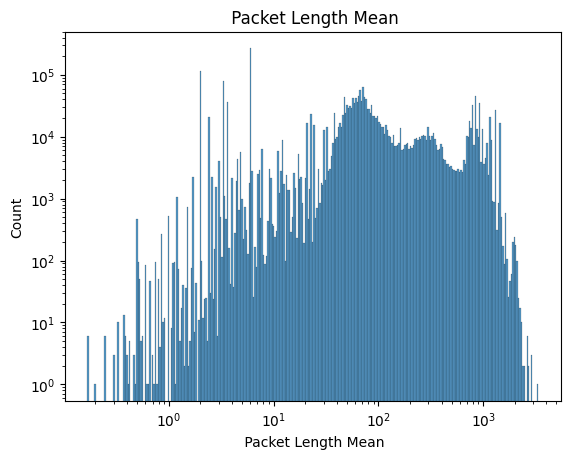

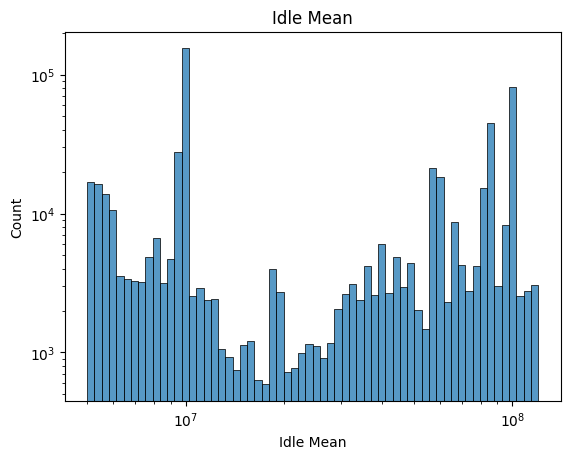

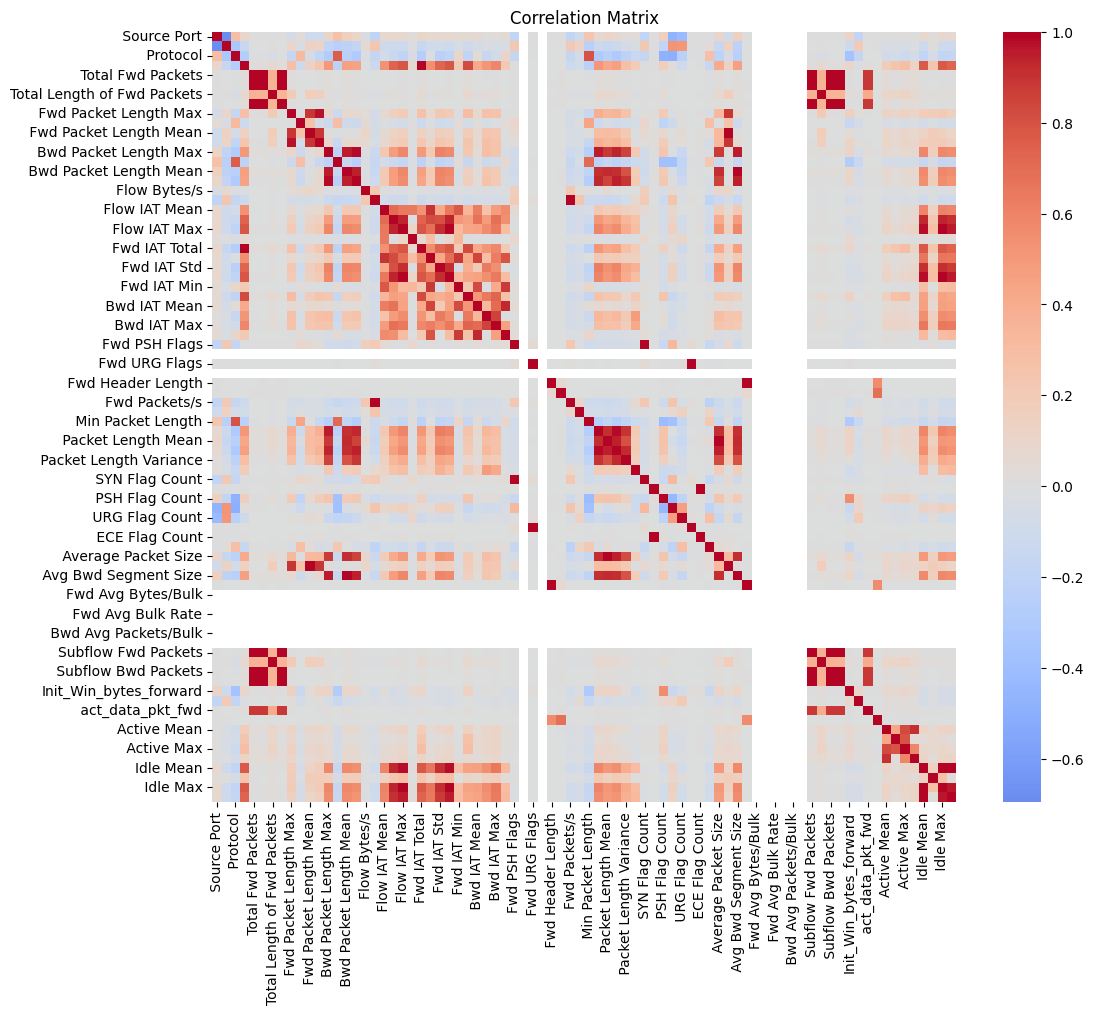

In [3]:
# Exploratory Data Analysis

# Print the basic structure of the dataset.
core_dataset.info()
display(core_dataset.describe())

# Show class distribution to understand how the classification
# problem must be approached.
core_dataset[' Label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.yscale('log')
plt.show()

numeric_cols = core_dataset.select_dtypes(include='number').columns

# Print metrics for invalid numeric data.
print("NaNs:")
display(core_dataset.isna().sum(axis=1).value_counts())
print("Infinities:")
display(np.isinf(core_dataset[numeric_cols]).sum(axis=1).value_counts())

# Print metrics for possible key features.

# Print the distribution of IP protocols with respect to the network flow type.
protocol_dist = pd.crosstab(core_dataset[' Label'], core_dataset[' Protocol'])
protocol_dist_pct = protocol_dist.div(protocol_dist.sum(axis=1), axis=0)
ax = protocol_dist_pct.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 8), 
    colormap='viridis'
)
plt.title('Distribution of Protocols per Traffic Label (Normalized)', fontsize=15)
plt.xlabel('Proportion of Traffic', fontsize=12)
plt.ylabel('Traffic Label', fontsize=12)
plt.legend(title='Protocol ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

metrics = [
    ' Flow Packets/s',
    ' Flow Duration',
    ' Packet Length Mean',
    'Idle Mean',
]

for col in metrics:
    seaborn.histplot(core_dataset[col], log_scale=True)
    plt.yscale('log')
    plt.title(col)
    plt.show()

# Compute and print correlation matrix 
corr = core_dataset[numeric_cols].corr()

plt.figure(figsize=(12,10))
seaborn.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [4]:
# Data conversion.
#
# This phase faciliates usage of the labelled data with NTLFlowLyzer
# (since CICFlowMeter depends on extremely outdated technology and I
# could get it to build in any environment I tried, including Docker
# and old NixOS packages).

feature_mapping = {
    # Easy direct mappings.
    "Flow ID": "flow_id",
    " Source IP": "src_ip",
    " Source Port": "src_port",
    " Destination IP": "dst_ip",
    " Destination Port": "dst_port",
    " Protocol": "protocol",
    " Timestamp": "timestamp",
    " Flow Duration": "duration",
    " Total Fwd Packets": "fwd_packets_count",
    " Total Backward Packets": "bwd_packets_count",
    
    "Total Length of Fwd Packets": "fwd_total_payload_bytes",
    " Total Length of Bwd Packets": "bwd_total_payload_bytes",
    " Fwd Packet Length Max": "fwd_payload_bytes_max",
    " Fwd Packet Length Min": "fwd_payload_bytes_min",
    " Fwd Packet Length Mean": "fwd_payload_bytes_mean",
    " Fwd Packet Length Std": "fwd_payload_bytes_std",
    "Bwd Packet Length Max": "bwd_payload_bytes_max",
    " Bwd Packet Length Min": "bwd_payload_bytes_min",
    " Bwd Packet Length Mean": "bwd_payload_bytes_mean",
    " Bwd Packet Length Std": "bwd_payload_bytes_std",
    "Flow Bytes/s": "bytes_rate",
    " Flow Packets/s": "packets_rate",
    " Flow IAT Mean": "packets_IAT_mean",
    " Flow IAT Std": "packet_IAT_std",
    " Flow IAT Max": "packet_IAT_max",
    " Flow IAT Min": "packet_IAT_min",
    "Fwd IAT Total": "fwd_packets_IAT_total",
    " Fwd IAT Mean": "fwd_packets_IAT_mean",
    " Fwd IAT Std": "fwd_packets_IAT_std",
    " Fwd IAT Max": "fwd_packets_IAT_max",
    " Fwd IAT Min": "fwd_packets_IAT_min",
    "Bwd IAT Total": "bwd_packets_IAT_total",
    " Bwd IAT Mean": "bwd_packets_IAT_mean",
    " Bwd IAT Std": "bwd_packets_IAT_std",
    " Bwd IAT Max": "bwd_packets_IAT_max",
    " Bwd IAT Min": "bwd_packets_IAT_min",
    "Fwd PSH Flags": "fwd_psh_flag_counts",
    " Bwd PSH Flags": "bwd_psh_flag_counts",
    " Fwd URG Flags": "fwd_urg_flag_counts",
    " Bwd URG Flags": "bwd_urg_flag_counts",
    " Fwd Header Length": "fwd_total_header_bytes",
    " Bwd Header Length": "bwd_total_header_bytes",
    "Fwd Packets/s": "fwd_packets_rate",
    " Bwd Packets/s": "bwd_packets_rate",
    " Min Packet Length": "payload_bytes_min",
    " Max Packet Length": "payload_bytes_max",
    " Packet Length Mean": "payload_bytes_mean",
    " Packet Length Std": "payload_bytes_std",
    " Packet Length Variance": "payload_bytes_variance",
    "FIN Flag Count": "fin_flag_counts",
    " SYN Flag Count": "syn_flag_counts",
    " RST Flag Count": "rst_flag_counts",
    " PSH Flag Count": "psh_flag_counts",
    " ACK Flag Count": "ack_flag_counts",
    " URG Flag Count": "urg_flag_counts",
    " CWE Flag Count": "cwr_flag_counts",
    " ECE Flag Count": "ece_flag_counts",
    " Down/Up Ratio": "down_up_rate",
    " Average Packet Size": "segment_size_mean",
    " Avg Fwd Segment Size": "fwd_segment_size_mean",
    " Avg Bwd Segment Size": "bwd_segment_size_mean",
    "Fwd Avg Bytes/Bulk": "avg_fwd_bytes_per_bulk",
    " Fwd Avg Packets/Bulk": "avg_fwd_packets_per_bulk",
    " Fwd Avg Bulk Rate": "avg_fwd_bulk_rate",
    " Bwd Avg Bytes/Bulk": "avg_bwd_bytes_per_bulk",
    " Bwd Avg Packets/Bulk": "avg_bwd_packets_bulk_rate",
    "Bwd Avg Bulk Rate": "avg_bwd_bulk_rate",
    "Subflow Fwd Packets": "subflow_fwd_packets",
    " Subflow Fwd Bytes": "subflow_fwd_bytes",
    " Subflow Bwd Packets": "subflow_bwd_packets",
    " Subflow Bwd Bytes": "subflow_bwd_bytes",
    "Init_Win_bytes_forward": "fwd_init_win_bytes",
    " Init_Win_bytes_backward": "bwd_init_win_bytes",
    " min_seg_size_forward": "fwd_segment_size_min",
    "Active Mean": "active_mean",
    " Active Std": "active_std",
    " Active Max": "active_max",
    " Active Min": "active_min",
    "Idle Mean": "idle_mean",
    " Idle Std": "idle_std",
    " Idle Max": "idle_max",
    " Idle Min": "idle_min",
    " Label": "label",
}

if len(feature_mapping.keys()) != len(core_dataset.columns):
    print(f"Columns Before: {len(feature_mapping.keys())}")
    print(f"Columns After: {len(core_dataset.columns)}")
    
    existing_columns = set(core_dataset.columns)
    expected_columns = set(feature_mapping.keys())
    dropped = existing_columns - expected_columns

    print(f"Dropped:")
    for col in sorted(list(dropped)):
        print(f" - '{col}'")

# The dropped features are
# - `Fwd Header Length.1`, which seems to be a duplicate of `Fwd Header Length`.
# - ` act_data_pkt_fwd`, doesn't have a corresponding feature in NTLFlowLyzer,
#   which is a replacement of CICFlowMeter (since CICFlowMeter depends on extremely
#   outdated technology and could not be gotten to build in any environment I tried,
#   including Docker and old NixOS packages).
df = core_dataset[feature_mapping.keys()].rename(columns = feature_mapping)

Columns Before: 83
Columns After: 85
Dropped:
 - ' Fwd Header Length.1'
 - ' act_data_pkt_fwd'


In [5]:
# Data cleaning

# Drop rows with all NaNs.
df = df.dropna(how='all')

In [6]:
# Convert data types.
df['src_port'] = df['src_port'].astype('uint16')
df['dst_port'] = df['dst_port'].astype('uint16')

df['protocol'] = df['protocol'].astype('uint16')

# Data conversion of `protocol` to be compatible with NTLFlowLyzer.
unique_protocols = df['protocol'].unique()
print(sorted(unique_protocols))

protocol_names = {
    6: 'TCP',
    17: 'UDP',
}

df['protocol'] = df['protocol'].map(protocol_names).fillna('Unknown').astype('category')

df['label'] = df['label'].astype('category')

[np.uint16(0), np.uint16(6), np.uint16(17)]


In [7]:
# Remove impossible data situations.
df = df[df['duration'] >= 0]
df = df[df['fwd_segment_size_min'] >= 0]

# Handle invalid/instantaneous flows (single packet flows have zero duration).
for c in ["bytes_rate", "packets_rate"]:
    df[c] = df[c].replace([np.inf, -np.inf], np.nan)
    df[c] = df[c].fillna(df[c].median())

# Drop these columns (Flow ID, Source IP, Destination IP, and Timestamp)
# These columns are not very general (all of them are not covered in their entirety
# and the IPs are constrained to a set of IPs that aren't relevant in the general case).
# Moreover, the attacks took place a highly specific times and thus would confuse any
# models.
to_drop = ['flow_id', 'src_ip', 'dst_ip', 'timestamp']
df = df.drop(columns=to_drop)

In [8]:
# Create additional features.

# Ratio between header and payload size (protocol overhead) is relevant
# to certain attacks.
df['fwd_header_payload_ratio'] = np.divide(
    df['fwd_total_header_bytes'].to_numpy(),
    df['fwd_total_payload_bytes'].to_numpy(),
    out=np.zeros_like(df['fwd_total_payload_bytes'].to_numpy(), dtype=float),
    where=df['fwd_total_payload_bytes'].to_numpy() != 0
)

df['bwd_header_payload_ratio'] = np.divide(
    df['bwd_total_header_bytes'].to_numpy(),
    df['bwd_total_payload_bytes'].to_numpy(),
    out=np.zeros_like(df['bwd_total_payload_bytes'].to_numpy(), dtype=float),
    where=df['bwd_total_payload_bytes'].to_numpy() != 0
)

# The ratio between activity and idleness may help identify type
# (interactive/bulk) or (short lived/long lived) of traffic and
# thus some attacks .
df['activity_ratio'] = np.divide(
    df['active_mean'].to_numpy(),
    df['idle_mean'].to_numpy(),
    out=np.zeros(len(df)),
    where=df['idle_mean'].to_numpy() != 0
)

# Normalize the variance of the packet lengths, which may identify
# certain types of patterns with fixed packet sizes.
df['payload_length_cov'] = np.divide(
    df['payload_bytes_std'].to_numpy(),
    df['payload_bytes_mean'].to_numpy(),
    out=np.zeros(len(df)),
    where=df['payload_bytes_mean'].to_numpy() != 0
)

In [9]:
# Implement feature selection.

# The correlation matrix heatmap demonstrates that there are many features with high correlation.
# Therefore we remove any features that have been identified as redundant.

# The correlation threshold before removal.
threshold = 0.95

corr = df.corr(numeric_only=True).abs().to_numpy()
upper = np.triu(np.ones(corr.shape), k=1).astype(bool)

to_drop = np.where((corr * upper) > threshold)
drop_cols = np.unique(to_drop[1])

cols_to_drop = sorted(df.columns[drop_cols].tolist())
print(f"Dropping ({len(cols_to_drop)} columns):")
for col in cols_to_drop:
    print(f"- {col}")

df = df.drop(df.columns[drop_cols], axis=1)

Dropping (24 columns):
- active_min
- avg_bwd_bulk_rate
- bwd_payload_bytes_mean
- bwd_payload_bytes_min
- bwd_total_header_bytes
- bwd_urg_flag_counts
- cwr_flag_counts
- down_up_rate
- fin_flag_counts
- fwd_packets_IAT_std
- fwd_packets_count
- fwd_payload_bytes_mean
- fwd_segment_size_mean
- fwd_total_header_bytes
- fwd_total_payload_bytes
- idle_max
- idle_std
- packet_IAT_min
- payload_bytes_mean
- segment_size_mean
- subflow_bwd_packets
- subflow_fwd_bytes
- subflow_fwd_packets
- urg_flag_counts


<class 'pandas.DataFrame'>
Index: 2830593 entries, 0 to 3119344
Data columns (total 59 columns):
 #   Column                     Dtype   
---  ------                     -----   
 0   src_port                   uint16  
 1   dst_port                   uint16  
 2   protocol                   category
 3   duration                   float64 
 4   bwd_packets_count          float64 
 5   bwd_total_payload_bytes    float64 
 6   fwd_payload_bytes_max      float64 
 7   fwd_payload_bytes_min      float64 
 8   fwd_payload_bytes_std      float64 
 9   bwd_payload_bytes_max      float64 
 10  bwd_payload_bytes_std      float64 
 11  bytes_rate                 float64 
 12  packets_rate               float64 
 13  packets_IAT_mean           float64 
 14  packet_IAT_std             float64 
 15  packet_IAT_max             float64 
 16  fwd_packets_IAT_total      float64 
 17  fwd_packets_IAT_mean       float64 
 18  fwd_packets_IAT_max        float64 
 19  fwd_packets_IAT_min        float64 
 

,src_port,dst_port,duration,bwd_packets_count,bwd_total_payload_bytes,fwd_payload_bytes_max,fwd_payload_bytes_min,fwd_payload_bytes_std,bwd_payload_bytes_max,bwd_payload_bytes_std,bytes_rate,packets_rate,packets_IAT_mean,packet_IAT_std,packet_IAT_max,fwd_packets_IAT_total,fwd_packets_IAT_mean,fwd_packets_IAT_max,fwd_packets_IAT_min,bwd_packets_IAT_total,bwd_packets_IAT_mean,bwd_packets_IAT_std,bwd_packets_IAT_max,bwd_packets_IAT_min,fwd_psh_flag_counts,bwd_psh_flag_counts,fwd_urg_flag_counts,fwd_packets_rate,bwd_packets_rate,payload_bytes_min,payload_bytes_max,payload_bytes_std,payload_bytes_variance,syn_flag_counts,rst_flag_counts,psh_flag_counts,ack_flag_counts,ece_flag_counts,bwd_segment_size_mean,avg_fwd_bytes_per_bulk,avg_fwd_packets_per_bulk,avg_fwd_bulk_rate,avg_bwd_bytes_per_bulk,avg_bwd_packets_bulk_rate,subflow_bwd_bytes,fwd_init_win_bytes,bwd_init_win_bytes,fwd_segment_size_min,active_mean,active_std,active_max,idle_mean,idle_min,fwd_header_payload_ratio,bwd_header_payload_ratio,activity_ratio,payload_length_cov
count,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2830593.0,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2830593.0,2830593.0,2830593.0,2830593.0,2830593.0,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06,2.830593e+06
mean,4.112951e+04,8.071193e+03,1.478587e+07,1.039422e+01,1.616350e+04,2.076100e+02,1.871383e+01,6.891374e+01,8.708949e+02,3.353435e+02,1.490687e+06,7.086363e+04,1.298483e+06,2.919321e+06,9.182543e+06,1.448315e+07,2.610258e+06,9.042998e+06,1.021935e+06,9.893848e+06,1.805802e+06,1.485905e+06,4.684543e+06,9.672993e+05,4.644892e-02,0.0,1.112841e-04,6.386797e+04,6.995553e+03,1.643461e+01,9.504516e+02,2.949910e+02,4.861805e+05,4.644892e-02,2.423520e-04,2.980863e-01,3.158204e-01,2.434119e-04,3.059648e+02,0.0,0.0,0.0,0.0,0.0,1.616316e+04,6.989830e+03,1.989089e+03,2.611580e+01,8.149167e+04,4.112192e+04,1.531151e+05,8.316124e+06,7.920152e+06,1.568746e+00,6.312602e-01,5.986671e-03,8.809754e-01
std,2.229453e+04,1.828336e+04,3.365408e+07,9.974147e+02,2.263148e+06,7.172025e+02,6.034067e+01,2.811941e+02,1.946409e+03,8.397119e+02,2.592687e+07,2.539755e+05,4.508044e+06,8.045997e+06,2.445977e+07,3.357615e+07,9.525935e+06,2.452939e+07,8.591661e+06,2.873680e+07,8.887390e+06,6.278404e+06,1.716080e+07,8.309200e+06,2.104553e-01,0.0,1.054854e-02,2.475424e+05,3.815268e+04,2.523773e+01,2.028272e+03,6.318132e+02,1.647530e+06,2.104553e-01,1.556578e-02,4.574177e-01,4.648419e-01,1.559977e-02,6.052691e+02,0.0,0.0,0.0,0.0,0.0,2.263117e+06,1.433857e+04,8.456116e+03,6.577133e+00,6.481236e+05,3.932937e+05,1.025474e+06,2.363037e+07,2.336374e+07,3.563685e+00,1.743879e+00,6.539814e-02,8.706344e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.670133e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.277600e+04,5.300000e+01,1.550000e+02,1.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.193495e+02,3.451440

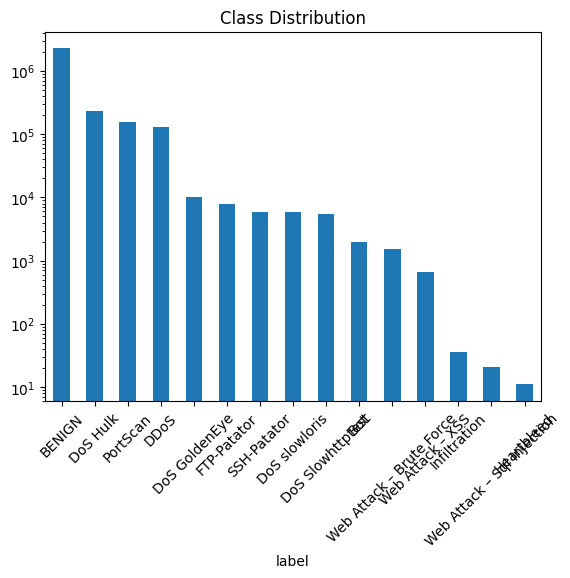

NaNs:


0    2830593
Name: count, dtype: int64

Infinities:


0    2830593
Name: count, dtype: int64

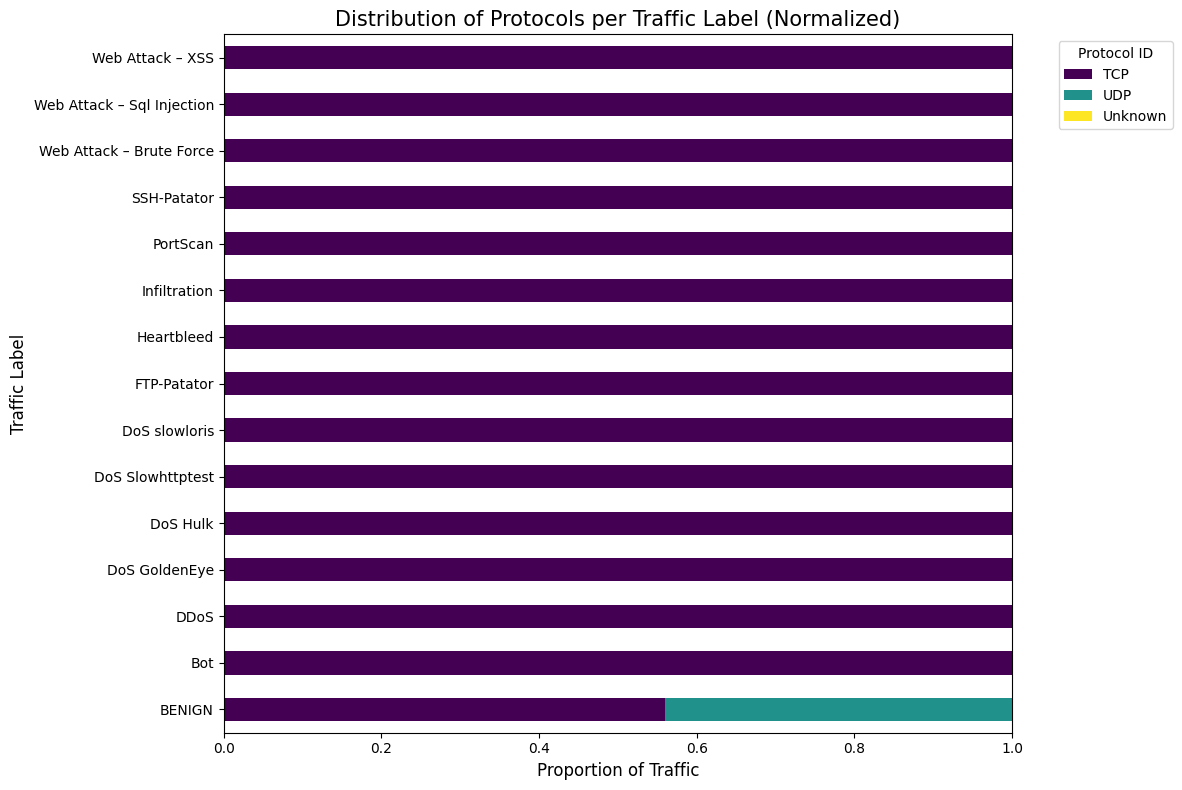

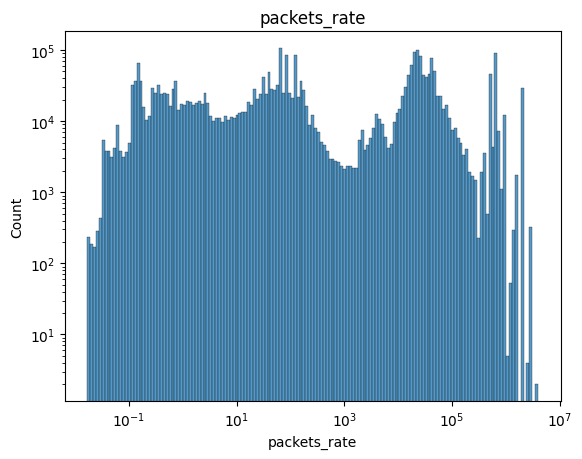

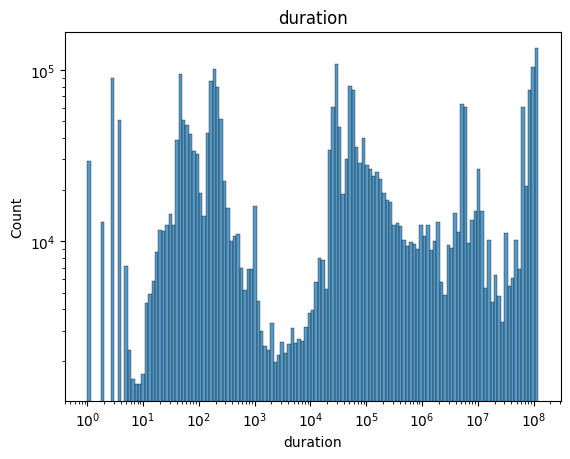

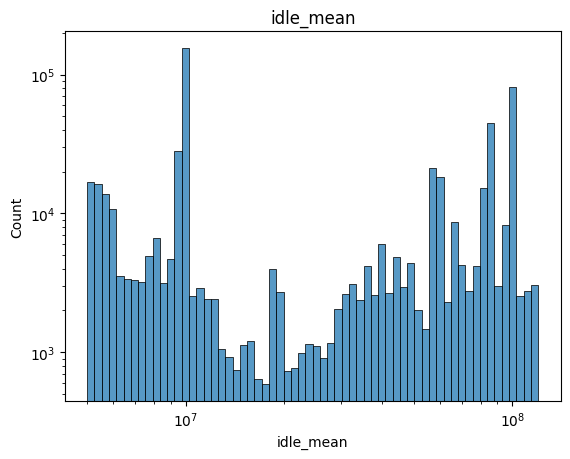

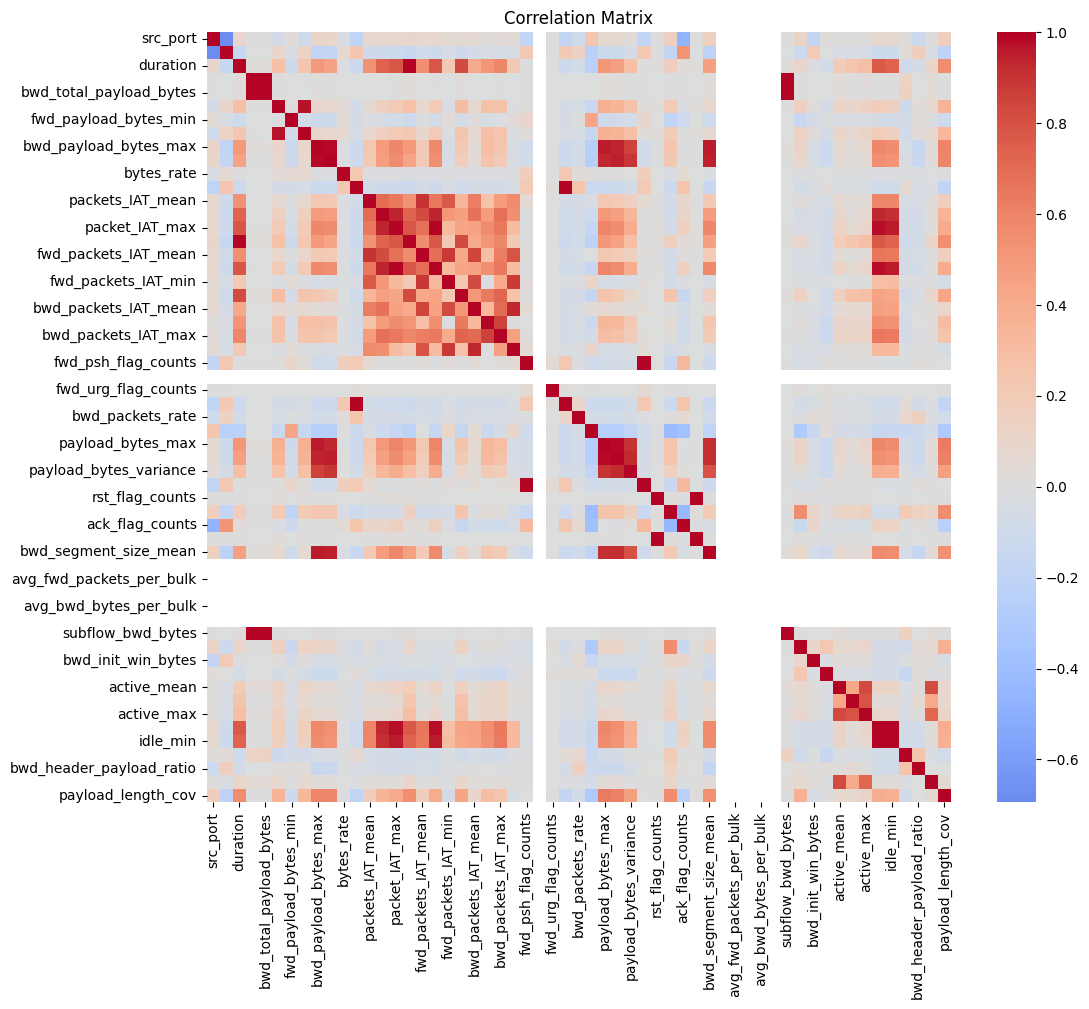

In [10]:
# Perform data analysis after cleaning and feature engineering.

# Print the basic structure of the dataset.
df.info()
display(df.describe())

# Show class distribution to understand how the classification
# problem must be approached.
df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.yscale('log')
plt.show()

numeric_cols = df.select_dtypes(include='number').columns

# Print metrics for invalid numeric data.
print("NaNs:")
display(df.isna().sum(axis=1).value_counts())
print("Infinities:")
display(np.isinf(df[numeric_cols]).sum(axis=1).value_counts())

# Print the distribution of IP protocols with respect to the network flow type.
protocol_dist = pd.crosstab(df['label'], df['protocol'])
protocol_dist_pct = protocol_dist.div(protocol_dist.sum(axis=1), axis=0)
ax = protocol_dist_pct.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 8), 
    colormap='viridis'
)
plt.title('Distribution of Protocols per Traffic Label (Normalized)', fontsize=15)
plt.xlabel('Proportion of Traffic', fontsize=12)
plt.ylabel('Traffic Label', fontsize=12)
plt.legend(title='Protocol ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

metrics = [
    'packets_rate',
    'duration',
    # 'payload_bytes_mean' THIS WAS REMOVED DURING FEATURE SELECTION
    'idle_mean'
]

for col in metrics:
    seaborn.histplot(df[col], log_scale=True)
    plt.yscale('log')
    plt.title(col)
    plt.show()

# Compute and print correlation matrix 
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
seaborn.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [11]:
# Encode the target label.
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

# Separate dataset into into features & the target.
X = df.drop(columns=['label'])
y = df['label']

# Split the data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Identify whcih columns are numerical or categorical.
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'string']).columns

preprocessor = ColumnTransformer(
    transformers=[
        # Apply scaling to numeric columns
        ('num', StandardScaler(), numeric_features),
        # Apply One-Hot Encoding to strings; handle_unknown='ignore' handles new values
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [12]:
class ContrastiveDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        # View 1: Mask 10% of features
        v1 = x.clone()
        mask1 = torch.rand(v1.shape) < 0.1
        v1[mask1] = 0
        
        # View 2: Add slight Gaussian noise
        noise = torch.randn(x.shape) * 0.01
        v2 = x + noise
        return v1, v2

class ContrastiveModel(nn.Module):
    def __init__(self, input_dim, embedding_dim=64):
        super().__init__()
        # The Encoder: This is what we keep for the final IDS
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embedding_dim)
        )
        # Projection Head: Used only during SSL pre-training
        self.projector = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, 32)
        )

    def forward(self, x):
        embedding = self.encoder(x)
        projection = self.projector(embedding)
        return embedding, projection

train_loader = DataLoader(ContrastiveDataset(X_train_scaled), batch_size=256, shuffle=True)
ssl_model = ContrastiveModel(input_dim=X_train_scaled.shape[1])
optimizer = optim.Adam(ssl_model.parameters(), lr=0.001)
criterion = nn.CosineSimilarity(dim=1)

ssl_model.train()
for epoch in range(10):
    print(f"Epoch {epoch}")
    for v1, v2 in train_loader:
        optimizer.zero_grad()
        _, p1 = ssl_model(v1)
        _, p2 = ssl_model(v2)
        loss = 1 - criterion(p1, p2).mean()
        loss.backward()
        optimizer.step()

ssl_model.eval()
with torch.no_grad():
    # Convert high-dim features into compact SSL embeddings
    X_train_ssl, _ = ssl_model(torch.tensor(X_train_scaled, dtype=torch.float32))
    X_test_ssl, _ = ssl_model(torch.tensor(preprocessor.transform(X_test), dtype=torch.float32))

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9


In [13]:
base_models = []
ssl_models = []

In [16]:
lr_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['saga']
}

print("Training base model")
base_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=100, class_weight='balanced', random_state=42),
    param_distributions=lr_param_grid,
    n_iter=3,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

base_lr.fit(X_train_scaled, y_train)
base_models.append((base_lr, "Linear Regression"))

print("Training SSL Model")
ssl_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=100, class_weight='balanced', random_state=42),
    param_distributions=lr_param_grid,
    n_iter=3,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

ssl_lr.fit(X_train_ssl, y_train)
ssl_models.append((ssl_lr, "Linear Regression (SSL)"))

Training base model


/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/jarl/documents/school/college/year

Training SSL Model


/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/utils/_indexing.py:63: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return array[key, ...] if axis == 0 else array[:, key]
/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/utils/_indexing.py:63: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before 

In [18]:
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print("Training base model")
base_rf = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced'),
    param_distributions=rf_param_grid,
    n_iter=3,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

base_rf.fit(X_train_scaled, y_train)
base_models.append((base_rf, "Random Forest"))

print("Training SSL Model")
ssl_rf = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42, class_weight='balanced'),
    param_distributions=rf_param_grid,
    n_iter=3,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

ssl_rf.fit(X_train_ssl, y_train)
ssl_models.append((ssl_rf, "Random Forest (SSL)"))

Training base model
Training SSL Model


/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/utils/_indexing.py:63: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return array[key, ...] if axis == 0 else array[:, key]
/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/utils/_indexing.py:63: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before 

In [27]:
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'tree_method': ['hist'],
}

print("Training base model")
base_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_distributions=xgb_param_grid,
    n_iter=3,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

base_xgb.fit(X_train_scaled, y_train)
base_models.append((base_xgb, "XGBoost"))

print("Training SSL Model")
ssl_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_distributions=xgb_param_grid,
    n_iter=3,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

ssl_xgb.fit(X_train_ssl, y_train)
ssl_models.append((ssl_xgb, "XGBoost (SSL)"))

Training base model
Training SSL Model


/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/utils/_indexing.py:63: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return array[key, ...] if axis == 0 else array[:, key]
/home/jarl/documents/school/college/year-3-spring/cs551/final-project/.venv/lib/python3.13/site-packages/sklearn/utils/_indexing.py:63: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before 

In [28]:
print(base_models)
print(ssl_models)

[(RandomizedSearchCV(cv=3,
                   estimator=LogisticRegression(class_weight='balanced',
                                                random_state=42),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'C': [0.1, 1.0, 10.0],
                                        'solver': ['saga']},
                   scoring='f1_macro'), 'Linear Regression'), (RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [50, 100]},
                   scoring='f1_macro'), 'Random Forest'), (RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier

In [29]:
def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (Macro)': precision_score(y_test, preds, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_test, preds, average='macro', zero_division=0),
        'F1-Score (Macro)': f1_score(y_test, preds, average='macro', zero_division=0)
    }

results = []

for model, name in base_models:
    results.append(evaluate_model(model, X_test_scaled, y_test, name))

for model, name in ssl_models:
    results.append(evaluate_model(model, X_test_ssl, y_test, name))


--- Model Comparison ---


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Linear Regression,0.668845,0.254210,0.797645,0.290389
1,Random Forest,0.997211,0.861420,0.859279,0.843920
2,XGBoost,0.998696,0.910145,0.836936,0.850885
3,Linear Regression (SSL),0.613306,0.240683,0.751227,0.268117
4,Random Forest (SSL),0.998398,0.917768,0.812324,0.828561
5,XGBoost (SSL),0.993157,0.900922,0.743885,0.774263


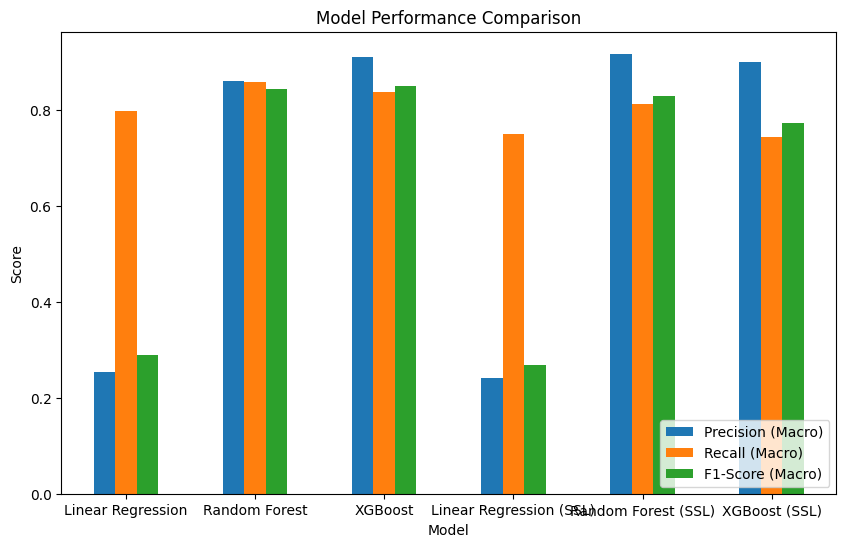

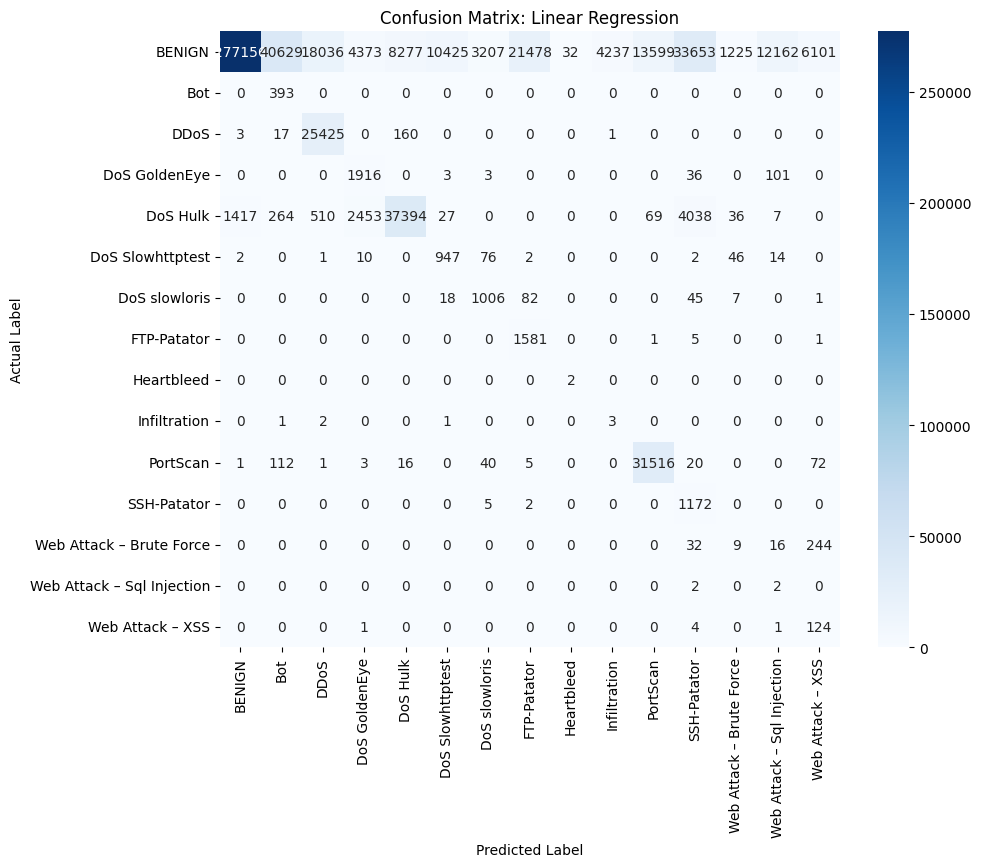

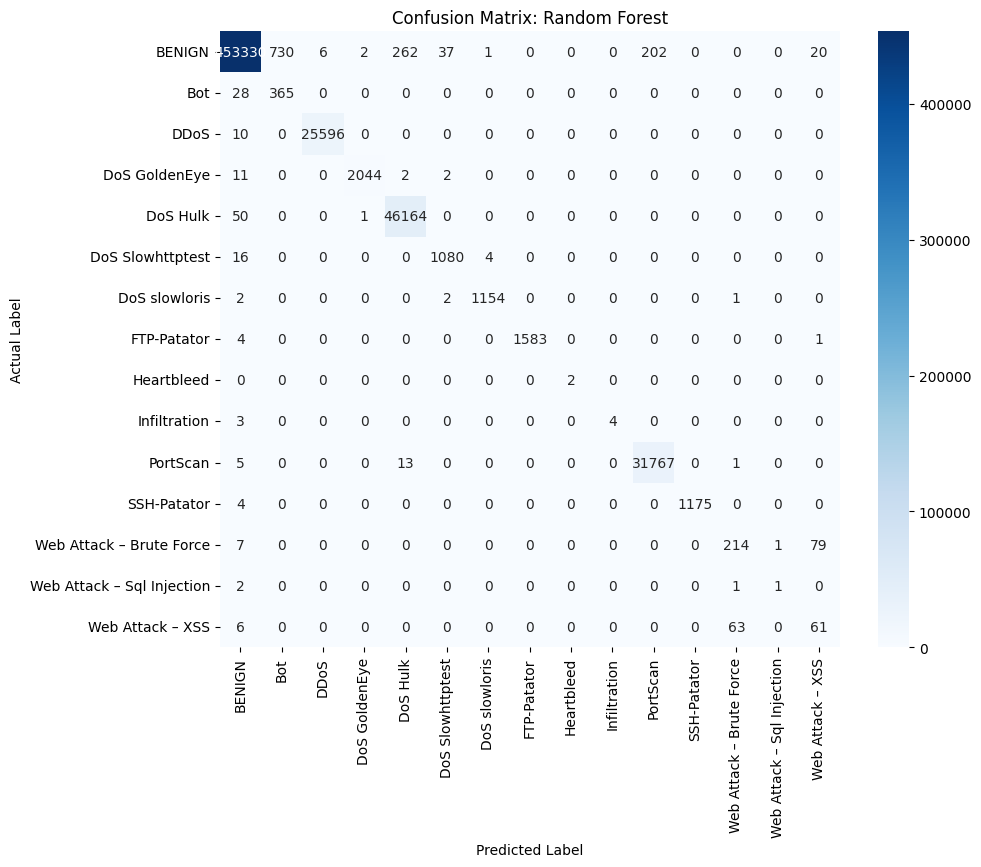

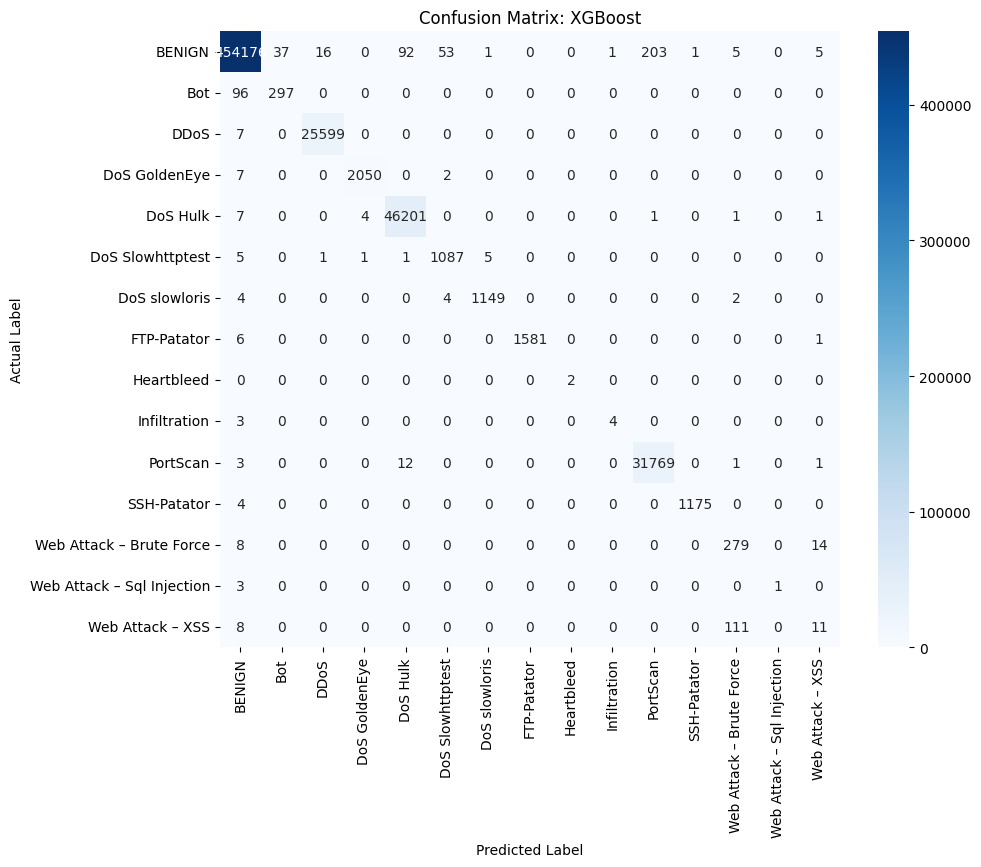

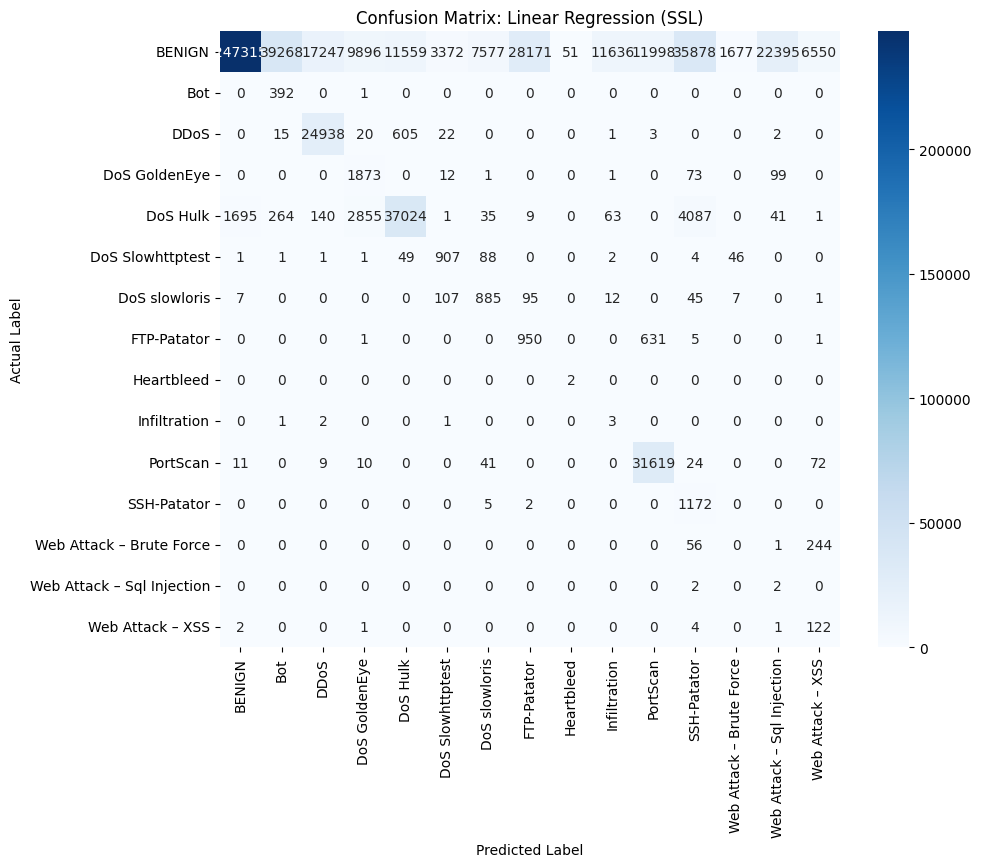

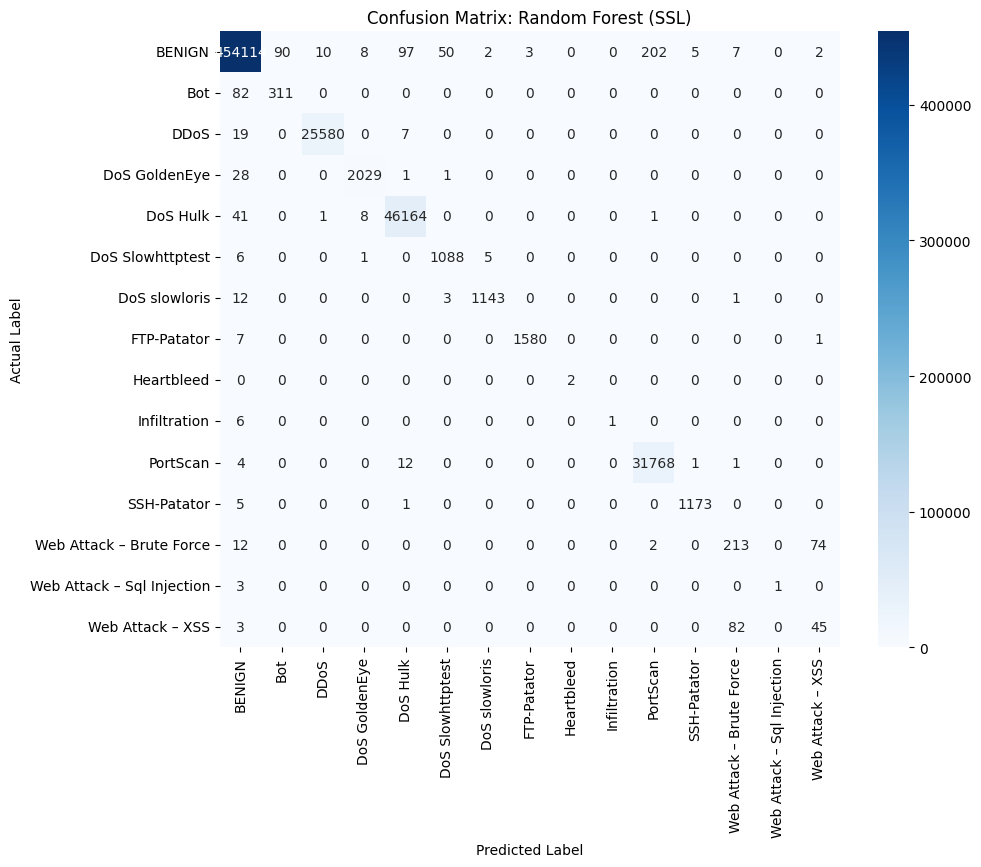

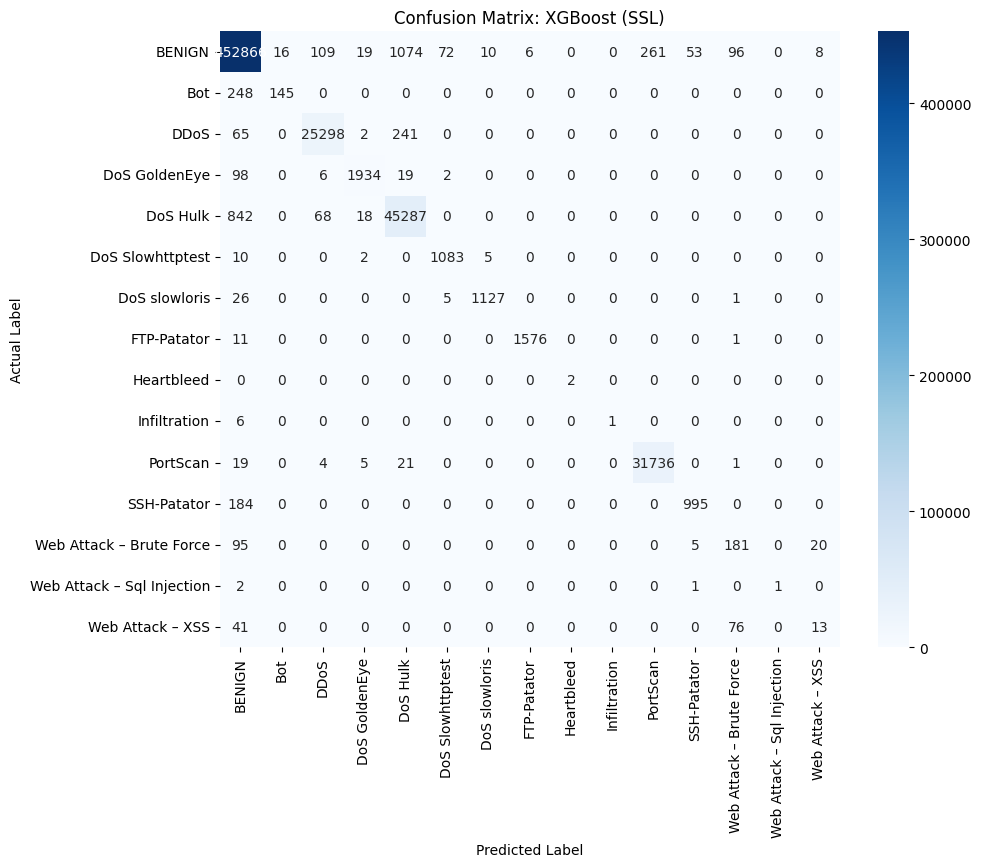

In [32]:
results_df = pd.DataFrame(results)
print("\n--- Model Comparison ---")
display(results_df)

# Visualizing the comparison
results_df.set_index('Model')[['Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']].plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# Get the original labels from the LabelEncoder
labels = le.classes_

for model, name in base_models:
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

for model, name in ssl_models:
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, model.predict(X_test_ssl))
    seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [31]:
dump(le, 'label_encoder.joblib')
dump(preprocessor, 'preprocessor.joblib')
torch.save(ssl_model.state_dict(), 'ssl_encoder.pth')

dump(X_train.columns.tolist(), 'selected_features.joblib')

dump(base_lr, 'base_linear_regression.joblib')
dump(ssl_lr, 'ssl_linear_regression.joblib')
dump(base_rf, 'base_random_forest.joblib')
dump(ssl_rf, 'ssl_random_forest.joblib')
dump(base_xgb, 'base_xgboost.joblib')
dump(ssl_xgb, 'ssl_xgboost.joblib')

['ssl_xgboost.joblib']